In [1]:
#hide
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

'[' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


In [2]:
#hide
from fastbook import *

# Collaborative Filtering Deep Dive

# 协同过滤深度挖掘

One very common problem to solve is when you have a number of users and a number of products, and you want to recommend which products are most likely to be useful for which users. There are many variations of this: for example, recommending movies (such as on Netflix), figuring out what to highlight for a user on a home page, deciding what stories to show in a social media feed, and so forth. There is a general solution to this problem, called *collaborative filtering*, which works like this: look at what products the current user has used or liked, find other users that have used or liked similar products, and then recommend other products that those users have used or liked.

For example, on Netflix you may have watched lots of movies that are science fiction, full of action, and were made in the 1970s. Netflix may not know these particular properties of the films you have watched, but it will be able to see that other people that have watched the same movies that you watched also tended to watch other movies that are science fiction, full of action, and were made in the 1970s. In other words, to use this approach we don't necessarily need to know anything about the movies, except who like to watch them.

There is actually a more general class of problems that this approach can solve, not necessarily involving users and products. Indeed, for collaborative filtering we more commonly refer to *items*, rather than *products*. Items could be links that people click on, diagnoses that are selected for patients, and so forth.

The key foundational idea is that of *latent factors*. In the Netflix example, we started with the assumption that you like old, action-packed sci-fi movies. But you never actually told Netflix that you like these kinds of movies. And Netflix never actually needed to add columns to its movies table saying which movies are of these types. Still, there must be some underlying concept of sci-fi, action, and movie age, and these concepts must be relevant for at least some people's movie watching decisions.

需要解决的一个非常常见的问题是，当你有许多用户和产品时，您想推荐哪些产品最有可能对哪些用户有用。这有很多变体：例如，推荐电影（例如在Netflix），确定在主页上为用户突出显示什么，决定在社交媒体提要中显示什么故事，等等。这个问题有一个通用的解决方案，叫做*协同过滤*，它的工作原理是这样的:查看当前用户使用过或喜欢的产品，找到其他使用过或喜欢类似产品的用户，然后推荐这些用户使用过或喜欢的其他产品。

例如，你可能在Netflix上看过很多20世纪70年代拍摄的充满动作场面的科幻电影。Netflix可能不知道你看过的电影的这些特定属性，但它可以看到，其他看过你看过的电影的人也倾向于看其他20世纪70年代制作的充满动作的科幻电影。换句话说，使用这种方法，我们不需要了解电影的任何信息，除了谁喜欢看他们。

实际上，这种方法可以解决更普遍的一类问题，不一定涉及用户和产品。事实上，对于协同过滤，我们更常提到*项目*，而不是*产品*。项目可以是人们点击的链接，为患者选择的诊断，等等。

关键的基本思想是*潜在因素*。在Netflix的例子中，我们一开始假设你喜欢古老的、充满动作的科幻电影。但你从来没有告诉Netflix你喜欢这类电影。而且Netflix并不需要在它的movies表中添加列来说明哪些电影属于这些类型。尽管如此，存在一些科幻、动作和电影时代的潜在概念，这些概念与一些人的观影决定相关。

For this chapter we are going to work on this movie recommendation problem. We'll start by getting some data suitable for a collaborative filtering model.

在本章中，我们将讨论电影推荐问题。我们将从获取一些适合于协同过滤模型的数据开始。

## A First Look at the Data

## 首先查看数据

We do not have access to Netflix's entire dataset of movie watching history, but there is a great dataset that we can use, called [MovieLens](https://grouplens.org/datasets/movielens/). This dataset contains tens of millions of movie rankings (a combination of a movie ID, a user ID, and a numeric rating), although we will just use a subset of 100,000 of them for our example. If you're interested, it would be a great learning project to try and replicate this approach on the full 25-million recommendation dataset, which you can get from their website.

我们无法访问Netflix的整个电影观看历史数据集，但我们可以使用一个很棒的数据集，叫做[MovieLens](https://grouplens.org/datasets/movielens/)。该数据集包含数千万个电影排名（电影ID、用户ID和数字评分的组合），尽管我们在示例中只使用其中的10万个子集。如果你感兴趣，可以尝试在完整的2500万个推荐数据集上复制这种方法将是一个很好的学习项目，你可以从他们的网站上获得完整数据集。

The dataset is available through the usual fastai function:

数据集可通过常用的fastai函数获得：

In [3]:
from fastai.collab import *
from fastai.tabular.all import *
path = untar_data(URLs.ML_100k)

According to the *README*, the main table is in the file *u.data*. It is tab-separated and the columns are, respectively user, movie, rating, and timestamp. Since those names are not encoded, we need to indicate them when reading the file with Pandas. Here is a way to open this table and take a look:

根据*README*，主表在文件*u.data*中。它是用制表符分隔的，列分别是用户、电影、评级和时间戳。由于这些名称没有编码，我们需要在使用Pandas读取文件时指出它们。这是打开此表并查看的一种方法：

In [4]:
ratings = pd.read_csv(path/'u.data', delimiter='\t', header=None,
                      names=['user','movie','rating','timestamp'])
ratings.head()

,user,movie,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


Although this has all the information we need, it is not a particularly helpful way for humans to look at this data. <<movie_xtab>> shows the same data cross-tabulated into a human-friendly table.

尽管这包含了我们需要的所有信息，但对我们来说，查看这些数据的方式并不是一种特别有帮助的方式。<<movie_xtab>>将相同的数据交叉列到一个对人类友好的表中。

<img alt="Crosstab of movies and users" width="632" caption="Crosstab of movies and users" id="movie_xtab" src="https://github.com/fastai/fastbook/blob/master/images/att_00040.png?raw=1">

We have selected just a few of the most popular movies, and users who watch the most movies, for this crosstab example. The empty cells in this table are the things that we would like our model to learn to fill in. Those are the places where a user has not reviewed the movie yet, presumably because they have not watched it. For each user, we would like to figure out which of those movies they might be most likely to enjoy.

If we knew for each user to what degree they liked each important category that a movie might fall into, such as genre, age, preferred directors and actors, and so forth, and we knew the same information about each movie, then a simple way to fill in this table would be to multiply this information together for each movie and use a combination. For instance, assuming these factors range between -1 and +1, with positive numbers indicating stronger matches and negative numbers weaker ones, and the categories are science-fiction, action, and old movies, then we could represent the movie *The Last Skywalker* as:

我们只选择了一些最受欢迎的电影，以及观看电影最多的用户，作为这个交叉表示例。此表中的空单元格是我们希望我们的模型学习填充的内容。这些空单元格是用户尚未评论电影的内容，可能是因为他们还没有看过。对于每个用户，我们都希望找出他们最可能喜欢的电影。

如果我们知道每个用户对电影可能属于的每个重要类别的喜爱程度，比如类型、年龄、喜欢的导演和演员，等等，并且我们知道每一部电影的相同信息，那么填写此表的一个简单方法是将每部电影的这些信息相乘，然后使用组合。例如，假设这些因素的范围在-1到+1之间，正数表示匹配更强，负数表示匹配更弱，并且类别是科幻电影、动作电影和老电影，那么我们可以将电影*最后的天行者*表示为：

In [5]:
last_skywalker = np.array([0.98,0.9,-0.9])

Here, for instance, we are scoring *very science-fiction* as 0.98, *very action* as 0.9, and *very not old* as -0.9. We could represent a user who likes modern sci-fi action movies as:

例如，*非常科幻*的评分为0.98，*非常动作*的评分为0.9，*非常不老*的评分为-0.9。我们可以将喜欢现代科幻动作电影的用户表示为：

In [6]:
user1 = np.array([0.9,0.8,-0.6])

and we can now calculate the match between this combination:

现在，我们可以计算这个组合之间的匹配：

In [7]:
(user1*last_skywalker).sum()

np.float64(2.1420000000000003)

When we multiply two vectors together and add up the results, this is known as the *dot product*. It is used a lot in machine learning, and forms the basis of matrix multiplication. We will be looking a lot more at matrix multiplication and dot products in <<chapter_foundations>>.

当我们将两个向量相乘并将结果相加时，这就是*点积*。它在机器学习中被大量使用，并构成矩阵乘法的基础。我们将在<<chapter_foundations>>中更多地学习矩阵乘法和点积。

> jargon: dot product: The mathematical operation of multiplying the elements of two vectors together, and then summing up the result.

>术语：点积:两个向量的元素相乘，然后将结果相加的数学运算。

On the other hand, we might represent the movie *Casablanca* as:

另一方面，我们可以把电影*《卡萨布兰卡》*表示为：

In [8]:
casablanca = np.array([-0.99,-0.3,0.8])

The match between this combination is:

此组合之间的匹配是：

In [9]:
(user1*casablanca).sum()

np.float64(-1.611)

Since we don't know what the latent factors actually are, and we don't know how to score them for each user and movie, we should learn them.

由于我们不知道真正的潜在因素是什么，也不知道如何为每个用户和电影进行评分，因此我们应该学习它们。

## Learning the Latent Factors

## 学习潜在因素

There is surprisingly little difference between specifying the structure of a model, as we did in the last section, and learning one, since we can just use our general gradient descent approach.

Step 1 of this approach is to randomly initialize some parameters. These parameters will be a set of latent factors for each user and movie. We will have to decide how many to use. We will discuss how to select this shortly, but for illustrative purposes let's use 5 for now. Because each user will have a set of these factors and each movie will have a set of these factors, we can show these randomly initialized values right next to the users and movies in our crosstab, and we can then fill in the dot products for each of these combinations in the middle. For example, <<xtab_latent>> shows what it looks like in Microsoft Excel, with the top-left cell formula displayed as an example.

正如我们在上一节中所做的那样，指定模型的结构和学习模型之间几乎没有区别，因为我们可以使用一般的梯度下降法。

这种方法的第一步是随机初始化一些参数。这些参数将是每个用户和电影的一组潜在因素。我们必须决定使用多少。我们稍后将讨论如何选择它，但出于说明的目的，我们现在使用5。因为每个用户都会有一组这样的因子，每个电影也会有一组这样的因子，所以我们可以在交叉表中的用户和电影旁边显示这些随机初始化的值，然后我们可以在中间填充这些组合的点积。例如，<<xtab_latent>>显示了它在Microsoft Excel中的样子，并以左上角的单元格公式为例。

<img alt="Latent factors with crosstab" width="900" caption="Latent factors with crosstab" id="xtab_latent" src="https://github.com/fastai/fastbook/blob/master/images/att_00041.png?raw=1">

Step 2 of this approach is to calculate our predictions. As we've discussed, we can do this by simply taking the dot product of each movie with each user. If, for instance, the first latent user factor represents how much the user likes action movies and the first latent movie factor represents if the movie has a lot of action or not, the product of those will be particularly high if either the user likes action movies and the movie has a lot of action in it or the user doesn't like action movies and the movie doesn't have any action in it. On the other hand, if we have a mismatch (a user loves action movies but the movie isn't an action film, or the user doesn't like action movies and it is one), the product will be very low.

Step 3 is to calculate our loss. We can use any loss function that we wish; let's pick mean squared error for now, since that is one reasonable way to represent the accuracy of a prediction.

That's all we need. With this in place, we can optimize our parameters (that is, the latent factors) using stochastic gradient descent, such as to minimize the loss. At each step, the stochastic gradient descent optimizer will calculate the match between each movie and each user using the dot product, and will compare it to the actual rating that each user gave to each movie. It will then calculate the derivative of this value and will step the weights by multiplying this by the learning rate. After doing this lots of times, the loss will get better and better, and the recommendations will also get better and better.

这个方法的第二步是计算我们的预测。正如我们所讨论的，我们可以通过简单地将每个电影与每个用户的点积来实现这一点。例如，如果第一个潜在用户因子表示用户有多喜欢动作片，第一个潜在电影因子表示电影是否有很多动作，如果用户喜欢动作片并且电影中有很多动作，或者用户不喜欢动作片并且电影中没有任何动作，则这些因子的点积将特别高。另一方面，如果我们存在不匹配（用户喜欢动作片但电影不是动作片，或者用户不喜欢动作片而电影是动作片），这些因子的点积将非常低。

第三步是计算损失。我们可以使用任何我们想要的损失函数；现在让我们选择均方误差，因为这是一种表示预测准确性的合理方法。

这就是我们所需要的。有了这个，我们可以使用随机梯度下降来优化我们的参数（即潜在因素），例如将损失最小化。在每个步骤中，随机梯度下降优化器将使用点积计算每部电影和每个用户之间的匹配度，并将其与每个用户给每部电影的实际评分进行比较。然后它会计算这个值的导数，并通过将其乘以学习率来更新权重。这样做很多次后，损失会越来越小，推荐也会越来越好。

To use the usual `Learner.fit` function we will need to get our data into a `DataLoaders`, so let's focus on that now.

要使用通常的`Learner.fit`函数，我们需要将数据放入`DataLoaders`，现在让我们关注这个问题。

## Creating the DataLoaders

## 创建数据加载器

When showing the data, we would rather see movie titles than their IDs. The table `u.item` contains the correspondence of IDs to titles:

在显示数据时，我们更愿意看到电影标题而不是它们的ID。表`u.item`包含ID与标题的对应关系：

In [10]:
movies = pd.read_csv(path/'u.item',  delimiter='|', encoding='latin-1',
                     usecols=(0,1), names=('movie','title'), header=None)
movies.head()

,movie,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


We can merge this with our `ratings` table to get the user ratings by title:

我们可以将其与我们的`ratings`表合并，以获得用户评分的标题:

In [11]:
ratings = ratings.merge(movies)
ratings.head()

,user,movie,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


We can then build a `DataLoaders` object from this table. By default, it takes the first column for the user, the second column for the item (here our movies), and the third column for the ratings. We need to change the value of `item_name` in our case to use the titles instead of the IDs:

然后，我们可以从此表构建一个`DataLoaders`对象。默认情况下，它的第一列表示用户，第二列表示项目(这里是我们的电影)，第三列表示评分。在本例中，我们需要更改`item_name`的值以使用标题而不是ID：

In [12]:
dls = CollabDataLoaders.from_df(ratings, item_name='title', bs=64)
dls.show_batch()

c:\Users\moxue\AppData\Local\Programs\Python\Python312\Lib\site-packages\fastai\torch_core.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  else as_tensor(x.values, **kwargs) if isinstance(x, (pd.Series, pd.DataFrame))


,user,title,rating
0,782,Starship Troopers (1997),2
1,943,Judge Dredd (1995),3
2,758,Mission: Impossible (1996),4
3,94,Farewell My Concubine (1993),5
4,23,Psycho (1960),4
5,296,Secrets & Lies (1996),5
6,940,"American President, The (1995)",4
7,334,Star Trek VI: The Undiscovered Country (1991),1
8,380,Braveheart (1995),4
9,690,So I Married an Axe Murderer (1993),1


To represent collaborative filtering in PyTorch we can't just use the crosstab representation directly, especially if we want it to fit into our deep learning framework. We can represent our movie and user latent factor tables as simple matrices:

为了在PyTorch中表示协同过滤，我们不能直接使用交叉表表示，尤其是如果我们希望它适合我们的深度学习框架。我们可以将电影和用户潜在因子表表示为简单的矩阵:

In [13]:
dls.classes

{'user': ['#na#', np.int16(1), np.int16(2), np.int16(3), np.int16(4), np.int16(5), np.int16(6), np.int16(7), np.int16(8), np.int16(9), np.int16(10), np.int16(11), np.int16(12), np.int16(13), np.int16(14), np.int16(15), np.int16(16), np.int16(17), np.int16(18), np.int16(19), np.int16(20), np.int16(21), np.int16(22), np.int16(23), np.int16(24), np.int16(25), np.int16(26), np.int16(27), np.int16(28), np.int16(29), np.int16(30), np.int16(31), np.int16(32), np.int16(33), np.int16(34), np.int16(35), np.int16(36), np.int16(37), np.int16(38), np.int16(39), np.int16(40), np.int16(41), np.int16(42), np.int16(43), np.int16(44), np.int16(45), np.int16(46), np.int16(47), np.int16(48), np.int16(49), np.int16(50), np.int16(51), np.int16(52), np.int16(53), np.int16(54), np.int16(55), np.int16(56), np.int16(57), np.int16(58), np.int16(59), np.int16(60), np.int16(61), np.int16(62), np.int16(63), np.int16(64), np.int16(65), np.int16(66), np.int16(67), np.int16(68), np.int16(69), np.int16(70), np.int16(71

In [14]:
n_users  = len(dls.classes['user'])
n_movies = len(dls.classes['title'])
print(n_users, n_movies)
n_factors = 5

user_factors = torch.randn(n_users, n_factors)
movie_factors = torch.randn(n_movies, n_factors)
user_factors.shape

944 1638


torch.Size([944, 5])

To calculate the result for a particular movie and user combination, we have to look up the index of the movie in our movie latent factor matrix and the index of the user in our user latent factor matrix; then we can do our dot product between the two latent factor vectors. But *look up in an index* is not an operation our deep learning models know how to do. They know how to do matrix products, and activation functions.

Fortunately, it turns out that we can represent *look up in an index* as a matrix product. The trick is to replace our indices with one-hot-encoded vectors. Here is an example of what happens if we multiply a vector by a one-hot-encoded vector representing the index 3:

为了计算特定电影和用户组合的结果，我们必须查找电影在电影潜在因子矩阵中的索引和用户在用户潜在因子矩阵中的索引；然后我们可以做两个潜在因子向量的点积。但是*在索引中查找*不是我们的深度学习模型所知道的操作。他们知道如何做矩阵乘积和激活函数。

幸运的是，我们可以将*在索引中查找*表示为矩阵乘积。诀窍是将我们的索引替换为独热编码向量。下面是一个例子，如果我们将一个向量乘以一个表示索引3的独热编码向量会发生什么:

In [15]:
one_hot_3 = one_hot(3, n_users).float()

In [16]:
user_factors[3]

tensor([-0.4586, -0.9915, -0.4052, -0.3621, -0.5908])

In [17]:
user_factors.t() @ one_hot_3

tensor([-0.4586, -0.9915, -0.4052, -0.3621, -0.5908])

It gives us the same vector as the one at index 3 in the matrix:

它为我们提供了与矩阵中索引3处相同的向量：

In [18]:
user_factors[3]

tensor([-0.4586, -0.9915, -0.4052, -0.3621, -0.5908])

If we do that for a few indices at once, we will have a matrix of one-hot-encoded vectors, and that operation will be a matrix multiplication! This would be a perfectly acceptable way to build models using this kind of architecture, except that it would use a lot more memory and time than necessary. We know that there is no real underlying reason to store the one-hot-encoded vector, or to search through it to find the occurrence of the number one—we should just be able to index into an array directly with an integer. Therefore, most deep learning libraries, including PyTorch, include a special layer that does just this; it indexes into a vector using an integer, but has its derivative calculated in such a way that it is identical to what it would have been if it had done a matrix multiplication with a one-hot-encoded vector. This is called an *embedding*.

如果我们同时对几个索引执行此操作，我们将得到一个由独热编码向量组成的矩阵，该操作将是矩阵乘法！这将是一种完全可以接受的使用这种架构构建模型的方法，除了它将使用大量不必要的内存和时间。我们知道没有真正的潜在因子来存储独热编码向量，或搜索它来找到数字1的出现——我们应该能够直接用整数索引数组。因此，包括PyTorch在内的大多数深度学习库都包含一个特殊的层来执行此操作；它使用整数索引到向量中，但其导数的计算方式与用独热编码的向量进行矩阵乘法相同。这就是所谓的*嵌入*。

> jargon: Embedding: Multiplying by a one-hot-encoded matrix, using the computational shortcut that it can be implemented by simply indexing directly. This is quite a fancy word for a very simple concept. The thing that you multiply the one-hot-encoded matrix by (or, using the computational shortcut, index into directly) is called the _embedding matrix_.

>术语：嵌入：乘以独热编码矩阵，使用可以通过简单地直接索引来实现的计算快捷方式。对于一个非常简单的概念来说，这是一个相当花哨的词。将独热编码矩阵乘以（或者使用计算快捷方式，直接索引到）的东西称为*嵌入矩阵*。

In computer vision, we have a very easy way to get all the information of a pixel through its RGB values: each pixel in a colored image is represented by three numbers. Those three numbers give us the redness, the greenness and the blueness, which is enough to get our model to work afterward.

For the problem at hand, we don't have the same easy way to characterize a user or a movie. There are probably relations with genres: if a given user likes romance, they are likely to give higher scores to romance movies. Other factors might be whether the movie is more action-oriented versus heavy on dialogue, or the presence of a specific actor that a user might particularly like. 

How do we determine numbers to characterize those? The answer is, we don't. We will let our model *learn* them. By analyzing the existing relations between users and movies, our model can figure out itself the features that seem important or not.

This is what embeddings are. We will attribute to each of our users and each of our movies a random vector of a certain length (here, `n_factors=5`), and we will make those learnable parameters. That means that at each step, when we compute the loss by comparing our predictions to our targets, we will compute the gradients of the loss with respect to those embedding vectors and update them with the rules of SGD (or another optimizer).

At the beginning, those numbers don't mean anything since we have chosen them randomly, but by the end of training, they will. By learning on existing data about the relations between users and movies, without having any other information, we will see that they still get some important features, and can isolate blockbusters from independent cinema, action movies from romance, and so on.

We are now in a position that we can create our whole model from scratch.

在计算机视觉中，我们有一种非常简单的方法，通过像素的RGB值获取像素的所有信息：彩色图像中的每个像素由三个数字表示。这三个数字给出了红色、绿色和蓝色，这足以让我们的模型在之后工作。

对于当前的问题，我们没有同样简单的方法来描述用户或电影。这可能与类型有关：如果特定的用户喜欢爱情片，他们可能会给爱情片更高的评分。其他因素可能是，电影是侧重于动作还是侧重于对话，或者可能有用户特别喜欢的演员的存在。

我们如何确定数字来表征这些？答案是，我们没有。我们将让我们的模型*学习*它们。通过分析用户与电影之间现有的关系，我们的模型可以自己找出那些看起来重要或不重要的特征。

这就是嵌入。我们将为每个用户和每个电影添加一个特定长度的随机向量（这里，`n_factors=5`），我们将使这些参数是可学习的。这意味着在每一步，当我们通过比较我们的预测和目标来计算损失时，我们将计算与那些嵌入向量相关的损失梯度，并使用SGD（或其他优化器）的规则更新它们。

一开始，这些数字没有任何意义，因为我们是随机选择的，但是在训练结束时，它们会有意义。通过学习现有的关于用户和电影之间关系的数据，在没有任何其他信息的情况下，我们会看到它们仍然得到一些重要的特征，可以将大片从独立电影中分离出来，将动作电影从爱情电影中分离出来，等等。

我们现在可以从头开始创建我们的整个模型。

## Collaborative Filtering from Scratch

## 从头开始协同过滤

Before we can write a model in PyTorch, we first need to learn the basics of object-oriented programming and Python. If you haven't done any object-oriented programming before, we will give you a quick introduction here, but we would recommend looking up a tutorial and getting some practice before moving on.

The key idea in object-oriented programming is the *class*. We have been using classes throughout this book, such as `DataLoader`, `string`, and `Learner`. Python also makes it easy for us to create new classes. Here is an example of a simple class:

在使用PyTorch编写模型之前，我们首先需要学习面向对象编程和Python的基础知识。如果您以前没有做过面向对象编程，我们将在这里给您一个快速的介绍，但是我们建议您在继续学习之前查阅教程并进行一些练习。

面向对象编程的关键思想是*类*。我们在本书中一直在使用类，例如`DataLoader`、`string`和`Learner`。Python还使我们可以轻松创建新类。下面是一个简单类的例子：

In [19]:
class Example:
    def __init__(self, a): self.a = a
    def say(self,x): return f'Hello {self.a}, {x}.'

The most important piece of this is the special method called `__init__` (pronounced *dunder init*). In Python, any method surrounded in double underscores like this is considered special. It indicates that there is some extra behavior associated with this method name. In the case of `__init__`, this is the method Python will call when your new object is created. So, this is where you can set up any state that needs to be initialized upon object creation. Any parameters included when the user constructs an instance of your class will be passed to the `__init__` method as parameters. Note that the first parameter to any method defined inside a class is `self`, so you can use this to set and get any attributes that you will need:

其中最重要的部分是名为`__init__`（发音为*dunder init*）的特殊方法。在Python中，任何像这样被双下划线包围的方法都被认为是特殊的。它表明有一些额外的行为与这个方法名相关联。在`__init__`的情况下，这是Python在创建新对象时将调用的方法。因此，这是您可以在创建对象时设置需要初始化状态的地方。当用户构造类的实例时，包含的任何参数都将作为参数传递给`__init__`方法。请注意，在类内部定义的任何方法的第一个参数是`self`，因此你可以使用它来设置和获取你需要的属性:

In [20]:
ex = Example('Sylvain')
ex.say('nice to meet you')

'Hello Sylvain, nice to meet you.'

Also note that creating a new PyTorch module requires inheriting from `Module`. *Inheritance* is an important object-oriented concept that we will not discuss in detail here—in short, it means that we can add additional behavior to an existing class. PyTorch already provides a `Module` class, which provides some basic foundations that we want to build on. So, we add the name of this *superclass* after the name of the class that we are defining, as shown in the following example.

The final thing that you need to know to create a new PyTorch module is that when your module is called, PyTorch will call a method in your class called `forward`, and will pass along to that any parameters that are included in the call. Here is the class defining our dot product model:

还要注意，创建一个新的PyTorch模块需要继承`Module`。*继承*是一个重要的面向对象的概念，我们不会在这里详细讨论——简而言之，它意味着我们可以向现有的类添加额外的行为。PyTorch已经提供了一个`Module`类，它提供了一些我们想要构建的基础。因此，我们将这个*超类*的名称添加到正在定义的类的名称之后，如以下示例所示。

要创建一个新的PyTorch模块，您需要知道的最后一件事是，当您的模块被调用时，PyTorch将调用类中的`forward`的方法，并将调用中包含的所有参数传递给该方法。下面是定义点积模型的类:

In [21]:
class DotProduct(Module):
    def __init__(self, n_users, n_movies, n_factors):
        self.user_factors = Embedding(n_users, n_factors)
        self.movie_factors = Embedding(n_movies, n_factors)

    def forward(self, x):
        users = self.user_factors(x[:,0])
        movies = self.movie_factors(x[:,1])
        return (users * movies).sum(dim=1)

If you haven't seen object-oriented programming before, then don't worry, you won't need to use it much in this book. We are just mentioning this approach here, because most online tutorials and documentation will use the object-oriented syntax.

Note that the input of the model is a tensor of shape `batch_size x 2`, where the first column (`x[:, 0]`) contains the user IDs and the second column (`x[:, 1]`) contains the movie IDs. As explained before, we use the *embedding* layers to represent our matrices of user and movie latent factors:

如果你之前没有见过面向对象编程，那么不用担心，在本书中你不需要过多地使用它。我们在这里只是提到这种方法，因为大多数在线教程和文档将使用面向对象语法。

注意，模型的输入是形状为`batch_size x 2`的张量，其中第一列（`x[:, 0]`）包含用户ID，第二列（`x[:, 1]`）包含电影ID。如前所述，我们使用*嵌入*层来表示用户和电影潜在因素的矩阵：

In [22]:
x,y = dls.one_batch()
x.shape

torch.Size([64, 2])

Now that we have defined our architecture, and created our parameter matrices, we need to create a `Learner` to optimize our model. In the past we have used special functions, such as `vision_learner`, which set up everything for us for a particular application. Since we are doing things from scratch here, we will use the plain `Learner` class:

现在我们已经定义了我们的架构，并创建了参数矩阵，我们需要创建一个`Learner`来优化我们的模型。过去我们使用了一些特殊的函数，例如`vision_learner`，它为我们设置了特定应用程序的所有内容。由于我们是从头开始，所以我们将使用普通的`Learner`类：

In [23]:
model = DotProduct(n_users, n_movies, 50)
learn = Learner(dls, model, loss_func=MSELossFlat())

We are now ready to fit our model:

现在我们已经准备好适合我们的模型:

In [24]:
learn.fit_one_cycle(5, 5e-3)

epoch,train_loss,valid_loss,time
0,1.326947,1.344186,00:07
1,1.051349,1.107274,00:08
2,0.904322,0.984433,00:08
3,0.786762,0.898634,00:07
4,0.742962,0.874542,00:08


The first thing we can do to make this model a little bit better is to force those predictions to be between 0 and 5. For this, we just need to use `sigmoid_range`, like in <<chapter_multicat>>. One thing we discovered empirically is that it's better to have the range go a little bit over 5, so we use `(0, 5.5)`:

为了让这个模型更好，我们能做的第一件事就是让这些预测在0到5之间。为此，我们只需要使用`sigmoid_range`，就像在<<chapter_multicat>>中一样。我们根据经验发现的一件事是最好让范围稍微超过5，所以我们使用`(0, 5.5)`：

In [ ]:
class DotProduct(Module):
    def __init__(self, n_users, n_movies, n_factors, y_range=(0,5.5)):
        self.user_factors = Embedding(n_users, n_factors)
        self.movie_factors = Embedding(n_movies, n_factors)
        self.y_range = y_range

    def forward(self, x):
        users = self.user_factors(x[:,0])
        movies = self.movie_factors(x[:,1])
        return sigmoid_range((users * movies).sum(dim=1), *self.y_range)

In [25]:
model = DotProduct(n_users, n_movies, 50)
learn = Learner(dls, model, loss_func=MSELossFlat())
learn.fit_one_cycle(5, 5e-3)

epoch,train_loss,valid_loss,time
0,1.338111,1.336249,00:08
1,1.018940,1.079630,00:08
2,0.881500,0.985139,00:08
3,0.788517,0.899416,00:08
4,0.763516,0.875899,00:08


This is a reasonable start, but we can do better. One obvious missing piece is that some users are just more positive or negative in their recommendations than others, and some movies are just plain better or worse than others. But in our dot product representation we do not have any way to encode either of these things. If all you can say about a movie is, for instance, that it is very sci-fi, very action-oriented, and very not old, then you don't really have any way to say whether most people like it. 

That's because at this point we only have weights; we do not have biases. If we have a single number for each user that we can add to our scores, and ditto for each movie, that will handle this missing piece very nicely. So first of all, let's adjust our model architecture:

这是一个合理的开始，但我们可以做得更好。一个明显缺失的部分是，一些用户的推荐比其他人更积极或更消极，而一些电影只是比其他电影更好或更差。但是在我们的点积表示中，我们没有任何方法来编码这些东西。例如，例如，如果你对一部电影的评价是，它非常科幻，非常以动作为导向，而且不是很古老，那么你真的无法判断大多数人是否喜欢它。 

这是因为在这一点上我们只有权重；我们没有偏见。如果我们为每个用户以及每部电影设置一个单独的数值，并将其添加到我们的分数中，我们便能够有效地处理这一缺失的部分。首先，让我们调整我们的模型架构:

In [30]:
class DotProductBias(Module):
    def __init__(self, n_users, n_movies, n_factors, y_range=(0,5.5)):
        self.user_factors = Embedding(n_users, n_factors)
        self.user_bias = Embedding(n_users, 1)
        self.movie_factors = Embedding(n_movies, n_factors)
        self.movie_bias = Embedding(n_movies, 1)
        self.y_range = y_range

    def forward(self, x):
        users = self.user_factors(x[:,0])
        movies = self.movie_factors(x[:,1])
        res = (users * movies).sum(dim=1, keepdim=True)
        res += self.user_bias(x[:,0]) + self.movie_bias(x[:,1])
        return sigmoid_range(res, *self.y_range)

Let's try training this and see how it goes:

让我们试着训练它，看看它是如何进行的：

In [31]:
model = DotProductBias(n_users, n_movies, 50)
learn = Learner(dls, model, loss_func=MSELossFlat())
learn.fit_one_cycle(5, 5e-3)

epoch,train_loss,valid_loss,time
0,0.875606,0.946436,00:09
1,0.595229,0.919201,00:09
2,0.414594,0.936632,00:09
3,0.317930,0.950860,00:09
4,0.306966,0.950922,00:09


Instead of being better, it ends up being worse (at least at the end of training). Why is that? If we look at both trainings carefully, we can see the validation loss stopped improving in the middle and started to get worse. As we've seen, this is a clear indication of overfitting. In this case, there is no way to use data augmentation, so we will have to use another regularization technique. One approach that can be helpful is *weight decay*.

它不但没有变得更好，反而变得更糟（至少在训练结束时）。这是为什么呢?如果我们仔细观察两次训练，我们可以看到验证损失在中间阶段停止改善，并开始变得更糟。正如我们所看到的，这是过度拟合的明显迹象。在这种情况下，没有办法使用数据增强，因此我们将不得不使用另一种正则化技术。一种有用的方法是*权重衰减*。

### Weight Decay

### 重量衰减

Weight decay, or *L2 regularization*, consists in adding to your loss function the sum of all the weights squared. Why do that? Because when we compute the gradients, it will add a contribution to them that will encourage the weights to be as small as possible.

Why would it prevent overfitting? The idea is that the larger the coefficients are, the sharper canyons we will have in the loss function. If we take the basic example of a parabola, `y = a * (x**2)`, the larger `a` is, the more *narrow* the parabola is (<<parabolas>>).

权重衰减，或者说*L2正则化*，包括将所有权重的平方之和添加到你的损失函数中。为什么要这样做？因为当我们计算梯度时，它会为它们添加一个贡献，从而鼓励权重尽可能小。

为什么它会防止过拟合？我们的想法是，系数越大，损失函数中的峡谷就越清晰。如果我们以抛物线为例，`y = a * (x**2)`，`a`越大，抛物线就越窄(<<parabolas>>)。

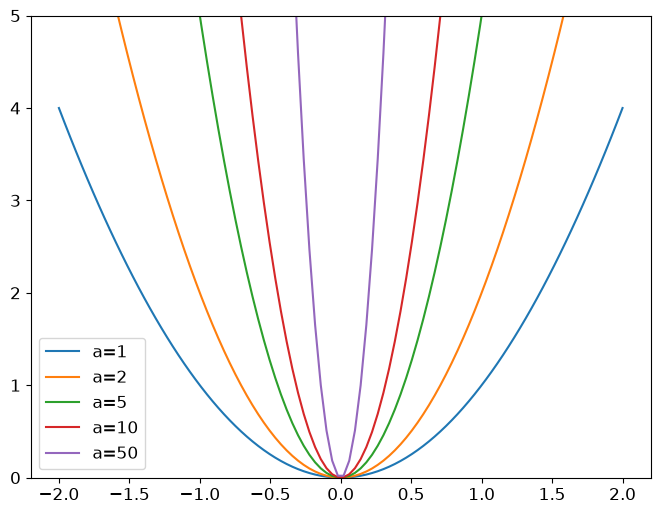

In [36]:
#hide_input
#id parabolas
x = np.linspace(-2,2,100)
a_s = [1,2,5,10,50]
ys = [a * x**2 for a in a_s]
_,ax = plt.subplots(figsize=(8,6))
for a,y in zip(a_s,ys): ax.plot(x,y, label=f'a={a}')
ax.set_ylim([0,5])
ax.legend();

So, letting our model learn high parameters might cause it to fit all the data points in the training set with an overcomplex function that has very sharp changes, which will lead to overfitting.

Limiting our weights from growing too much is going to hinder the training of the model, but it will yield a state where it generalizes better. Going back to the theory briefly, weight decay (or just `wd`) is a parameter that controls that sum of squares we add to our loss (assuming `parameters` is a tensor of all parameters):

``` python
loss_with_wd = loss + wd * (parameters**2).sum()
```

In practice, though, it would be very inefficient (and maybe numerically unstable) to compute that big sum and add it to the loss. If you remember a little bit of high school math, you might recall that the derivative of `p**2` with respect to `p` is `2*p`, so adding that big sum to our loss is exactly the same as doing:

``` python
parameters.grad += wd * 2 * parameters
```

In practice, since `wd` is a parameter that we choose, we can just make it twice as big, so we don't even need the `*2` in this equation. To use weight decay in fastai, just pass `wd` in your call to `fit` or `fit_one_cycle`:

因此，让我们的模型学习高参数可能会导致它用一个变化非常剧烈的过于复杂的函数来拟合训练集中的所有数据点，这将导致过度拟合。

限制我们的权重增长太多会阻碍模型的训练，但它会产生一种更好地泛化的状态。简单地回到理论，权重衰减（或只是`wd`）是一个控制我们添加到损失中的平方和的参数（假设`parameters`是所有参数的张量）：


``` python
loss_with_wd = loss + wd * (parameters**2).sum()
```

然而，在实践中，计算这个大数并将其添加到损失中是非常低效的（并且可能在数值上不稳定）。如果你还记得一点高中数学，你可能会记得`p**2`相对于`p`的导数是`2*p`，所以将这个大数添加到我们的损失中与这样做完全相同：

``` python
parameters.grad += wd * 2 * parameters
```

在实践中，由于`wd`是我们选择的参数，我们可以将其放大两倍，因此我们甚至不需要此方程中的`*2`。要在fastai中使用权重衰减，只需将调用中的`wd`传递给`fit`或`fit_one_cycle`：

In [41]:
model = DotProductBias(n_users, n_movies, 50)
learn = Learner(dls, model, loss_func=MSELossFlat())
learn.fit_one_cycle(5, 5e-3, wd=0.1)

epoch,train_loss,valid_loss,time
0,0.889496,0.932446,00:09
1,0.652055,0.886801,00:09
2,0.532687,0.863971,00:09
3,0.463015,0.848686,00:09
4,0.431384,0.845566,00:09


Much better!

好多了！

### Creating Our Own Embedding Module

### 创建我们自己的嵌入模块

So far, we've used `Embedding` without thinking about how it really works. Let's re-create `DotProductBias` *without* using this class. We'll need a randomly initialized weight matrix for each of the embeddings. We have to be careful, however. Recall from <<chapter_mnist_basics>> that optimizers require that they can get all the parameters of a module from the module's `parameters` method. However, this does not happen fully automatically. If we just add a tensor as an attribute to a `Module`, it will not be included in `parameters`:

到目前为止，我们使用了`Embedding`，但没有考虑它的实际工作原理。让我们在*不使用*这个类的情况下重新创建`DotProductBias`。我们需要为每个嵌入随机初始化权重矩阵。但是，我们必须小心。回想一下<<chapter_mnist_basics>>中，优化器要求他们可以从模块的`parameters`方法中获取模块的所有参数。但是，这并不是完全自动发生的。如果我们只是将张量作为属性添加到`Module`中，它将不会包含在`parameters`中：

In [48]:
class T(Module):
    def __init__(self): self.a = torch.ones(3)

L(T().parameters())

[]

To tell `Module` that we want to treat a tensor as a parameter, we have to wrap it in the `nn.Parameter` class. This class doesn't actually add any functionality (other than automatically calling `requires_grad_` for us). It's only used as a "marker" to show what to include in `parameters`:

为了告诉`Module`我们要将张量视为参数，我们必须将其包装在`nn.Parameter`类中。这个类实际上并没有添加任何功能（除了为我们自动调用`requires_grad_`）。它只是作为一个“标记”来显示`parameters`中包含的内容：

In [43]:
class T(Module):
    def __init__(self): self.a = nn.Parameter(torch.ones(3))

L(T().parameters())

[Parameter containing:
tensor([1., 1., 1.], requires_grad=True)]

All PyTorch modules use `nn.Parameter` for any trainable parameters, which is why we haven't needed to explicitly use this wrapper up until now:

所有PyTorch模块对任何可训练参数都使用`nn.Parameter`，这就是为什么我们到目前为止还不需要显式使用这个包装器的原因：

In [45]:
class T(Module):
    def __init__(self): self.a = nn.Linear(1, 3, bias=False)

t = T()
L(t.parameters())

[Parameter containing:
tensor([[ 0.1538],
        [ 0.9243],
        [-0.6000]], requires_grad=True)]

In [46]:
type(t.a.weight)

torch.nn.parameter.Parameter

We can create a tensor as a parameter, with random initialization, like so:

我们可以创建一个张量作为参数，进行随机初始化，如下所示：

In [47]:
def create_params(size):
    return nn.Parameter(torch.zeros(*size).normal_(0, 0.01))

Let's use this to create `DotProductBias` again, but without `Embedding`:

让我们使用它再次创建`DotProductBias`，但没有`Embedding`：

In [49]:
class DotProductBias(Module):
    def __init__(self, n_users, n_movies, n_factors, y_range=(0,5.5)):
        self.user_factors = create_params([n_users, n_factors])
        self.user_bias = create_params([n_users])
        self.movie_factors = create_params([n_movies, n_factors])
        self.movie_bias = create_params([n_movies])
        self.y_range = y_range

    def forward(self, x):
        users = self.user_factors[x[:,0]]
        movies = self.movie_factors[x[:,1]]
        res = (users*movies).sum(dim=1)
        res += self.user_bias[x[:,0]] + self.movie_bias[x[:,1]]
        return sigmoid_range(res, *self.y_range)

Then let's train it again to check we get around the same results we saw in the previous section:

然后让我们再次训练它以检查我们是否获得了与上一节中看到的相同的结果：

In [50]:
model = DotProductBias(n_users, n_movies, 50)
learn = Learner(dls, model, loss_func=MSELossFlat())
learn.fit_one_cycle(5, 5e-3, wd=0.1)

epoch,train_loss,valid_loss,time
0,0.887852,0.942333,00:11
1,0.669128,0.897440,00:11
2,0.514059,0.869074,00:11
3,0.455386,0.854549,00:10
4,0.424973,0.849200,00:10


Now, let's take a look at what our model has learned.

现在，让我们看看我们的模型学到了什么。

## Interpreting Embeddings and Biases

## 解释嵌入和偏见

Our model is already useful, in that it can provide us with movie recommendations for our users—but it is also interesting to see what parameters it has discovered. The easiest to interpret are the biases. Here are the movies with the lowest values in the bias vector:

我们的模型已经很有用了，因为它可以为我们的用户提供电影推荐——但看看它发现了什么参数也很有趣。最容易解释的是偏见。以下是偏见向量中值最低的电影：

In [ ]:
movie_bias = learn.model.movie_bias.squeeze()
idxs = movie_bias.argsort()[:5]
[dls.classes['title'][i] for i in idxs]

['Children of the Corn: The Gathering (1996)',
 'Lawnmower Man 2: Beyond Cyberspace (1996)',
 'Beautician and the Beast, The (1997)',
 'Crow: City of Angels, The (1996)',
 'Home Alone 3 (1997)']

Think about what this means. What it's saying is that for each of these movies, even when a user is very well matched to its latent factors (which, as we will see in a moment, tend to represent things like level of action, age of movie, and so forth), they still generally don't like it. We could have simply sorted the movies directly by their average rating, but looking at the learned bias tells us something much more interesting. It tells us not just whether a movie is of a kind that people tend not to enjoy watching, but that people tend not to like watching it even if it is of a kind that they would otherwise enjoy! By the same token, here are the movies with the highest bias:

想想这意味着什么。它的意思是，对于每一部电影，即使用户与其潜在因素非常匹配（正如我们稍后将看到的，这些因素往往代表动作水平、电影年龄等），他们仍然不喜欢它。我们本可以直接根据平均评分对电影进行排序，但观察习得偏见告诉我们一些更有趣的事情。它不仅告诉我们一部电影是否属于人们不喜欢看的类型，而且还告诉我们，即使这部电影是他们本来喜欢的类型，人们也不喜欢看。出于同样的原因，以下是偏见最大的电影:

In [ ]:
idxs = movie_bias.argsort(descending=True)[:5]
[dls.classes['title'][i] for i in idxs]

['L.A. Confidential (1997)',
 'Titanic (1997)',
 'Silence of the Lambs, The (1991)',
 'Shawshank Redemption, The (1994)',
 'Star Wars (1977)']

So, for instance, even if you don't normally enjoy detective movies, you might enjoy *LA Confidential*!

It is not quite so easy to directly interpret the embedding matrices. There are just too many factors for a human to look at. But there is a technique that can pull out the most important underlying *directions* in such a matrix, called *principal component analysis* (PCA). We will not be going into this in detail in this book, because it is not particularly important for you to understand to be a deep learning practitioner, but if you are interested then we suggest you check out the fast.ai course [Computational Linear Algebra for Coders](https://github.com/fastai/numerical-linear-algebra). <<img_pca_movie>> shows what our movies look like based on two of the strongest PCA components.

所以，例如，即使你通常不喜欢侦探电影，你也可能喜欢*《洛杉矶机密》*！

直接解释嵌入矩阵并不是那么容易。对于人类来说，有太多的因素需要考虑。但是有一种技术可以在这样的矩阵中提取出最重要的潜在*方向*，称为*主成分分析*（PCA）。我们不会在这本书中详细讨论这个问题，因为它对你理解成为一个深度学习实践者不是特别重要，但如果你有兴趣，我们建议你查看fast.ai课程[计算线性代数程序员](https://github.com/fastai/numerical-linear-algebra)。<<img_pca_movie>>显示了基于两个最强的PCA组件的电影。

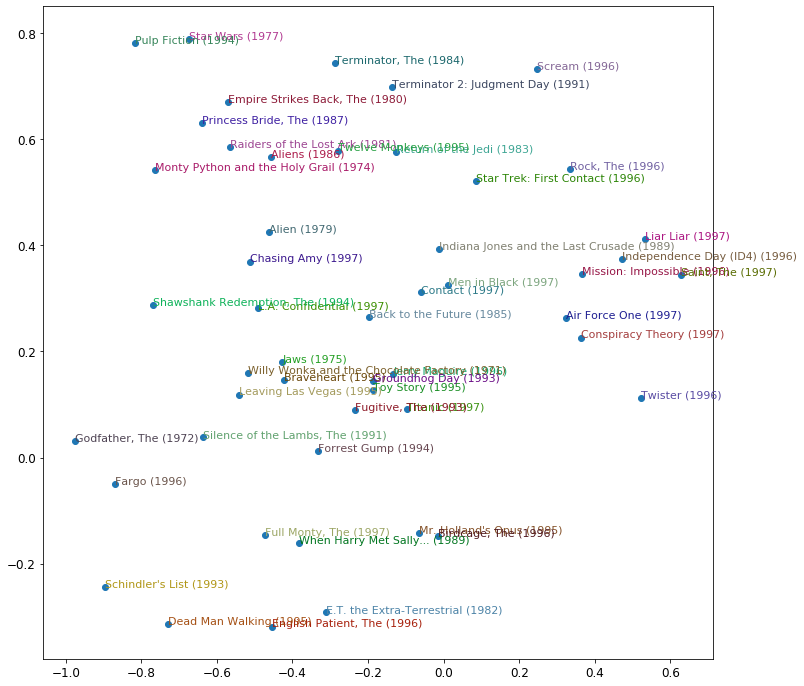

In [ ]:
#hide_input
#id img_pca_movie
#caption Representation of movies based on two strongest PCA components
#alt Representation of movies based on two strongest PCA components
g = ratings.groupby('title')['rating'].count()
top_movies = g.sort_values(ascending=False).index.values[:1000]
top_idxs = tensor([learn.dls.classes['title'].o2i[m] for m in top_movies])
movie_w = learn.model.movie_factors[top_idxs].cpu().detach()
movie_pca = movie_w.pca(3)
fac0,fac1,fac2 = movie_pca.t()
idxs = list(range(50))
X = fac0[idxs]
Y = fac2[idxs]
plt.figure(figsize=(12,12))
plt.scatter(X, Y)
for i, x, y in zip(top_movies[idxs], X, Y):
    plt.text(x,y,i, color=np.random.rand(3)*0.7, fontsize=11)
plt.show()

We can see here that the model seems to have discovered a concept of *classic* versus *pop culture* movies, or perhaps it is *critically acclaimed* that is represented here.

我们可以在这里看到，该模型似乎发现了*经典*与*流行文化*电影的概念，或者这里所代表的可能是*广受好评*。

> j: No matter how many models I train, I never stop getting moved and surprised by how these randomly initialized bunches of numbers, trained with such simple mechanics, manage to discover things about my data all by themselves. It almost seems like cheating, that I can create code that does useful things without ever actually telling it how to do those things!

>j：不管我训练了多少个模型，我总是会对这些随机初始化的数字组，用如此简单的机制训练，自己发现关于我的数据的事情感到感动和惊讶。这几乎像是作弊，我可以创建代码来做有用的事情，而不需要实际告诉它如何做这些事情!

We defined our model from scratch to teach you what is inside, but you can directly use the fastai library to build it. We'll look at how to do that next.

我们从头开始定义我们的模型来教你里面有什么，但是你可以直接使用Fastai库来构建它。接下来我们将看看如何做到这一点。

### Using fastai.collab

### 使用 fastai.collab

We can create and train a collaborative filtering model using the exact structure shown earlier by using fastai's `collab_learner`:

通过使用fastai的`collab_learner`，我们可以使用前面展示的确切结构创建和训练协同过滤模型：

In [ ]:
learn = collab_learner(dls, n_factors=50, y_range=(0, 5.5))

In [ ]:
learn.fit_one_cycle(5, 5e-3, wd=0.1)

epoch,train_loss,valid_loss,time
0,0.931751,0.953806,00:13
1,0.851826,0.878119,00:13
2,0.715254,0.834711,00:13
3,0.583173,0.821470,00:13
4,0.496625,0.821688,00:13


The names of the layers can be seen by printing the model:

通过打印模型可以看到层的名称：

In [ ]:
learn.model

EmbeddingDotBias(
  (u_weight): Embedding(944, 50)
  (i_weight): Embedding(1635, 50)
  (u_bias): Embedding(944, 1)
  (i_bias): Embedding(1635, 1)
)

We can use these to replicate any of the analyses we did in the previous section—for instance:

我们可以使用这些来复制我们在上一节中所做的所有分析-例如：

In [ ]:
movie_bias = learn.model.i_bias.weight.squeeze()
idxs = movie_bias.argsort(descending=True)[:5]
[dls.classes['title'][i] for i in idxs]

['Titanic (1997)',
 "Schindler's List (1993)",
 'Shawshank Redemption, The (1994)',
 'L.A. Confidential (1997)',
 'Silence of the Lambs, The (1991)']

Another interesting thing we can do with these learned embeddings is to look at _distance_.

我们可以用这些学习过的嵌入做的另一件有趣的事情是查看距离。

### Embedding Distance

### 嵌入距离

On a two-dimensional map we can calculate the distance between two coordinates using the formula of Pythagoras: $\sqrt{x^{2}+y^{2}}$ (assuming that *x* and *y* are the distances between the coordinates on each axis). For a 50-dimensional embedding we can do exactly the same thing, except that we add up the squares of all 50 of the coordinate distances.

If there were two movies that were nearly identical, then their embedding vectors would also have to be nearly identical, because the users that would like them would be nearly exactly the same. There is a more general idea here: movie similarity can be defined by the similarity of users that like those movies. And that directly means that the distance between two movies' embedding vectors can define that similarity. We can use this to find the most similar movie to *Silence of the Lambs*:

在二维地图上，我们可以使用毕达哥拉斯公式计算两个坐标之间的距离：$\sqrt{x^{2}+y^{2}}$（假设*x*和*y*是每个轴上坐标之间的距离）。对于50维的嵌入，我们可以做完全相同的事情，只是我们将所有50个坐标距离的平方相加。

如果有两个几乎相同的电影，那么它们的嵌入向量也必须是几乎相同的，因为喜欢它们的用户几乎完全相同。这里有一个更普遍的概念:电影相似性可以通过喜欢这些电影的用户的相似性来定义。这直接意味着两部电影嵌入向量之间的距离可以定义这种相似性。我们可以用它来找到与*《沉默的羔羊》*最相似的电影：

In [ ]:
movie_factors = learn.model.i_weight.weight
idx = dls.classes['title'].o2i['Silence of the Lambs, The (1991)']
distances = nn.CosineSimilarity(dim=1)(movie_factors, movie_factors[idx][None])
idx = distances.argsort(descending=True)[1]
dls.classes['title'][idx]

'Dial M for Murder (1954)'

Now that we have succesfully trained a model, let's see how to deal with the situation where we have no data for a user. How can we make recommendations to new users?

现在我们已经成功地训练了一个模型，让我们看看如何处理我们没有用户数据的情况。我们如何向新用户进行推荐？

## Bootstrapping a Collaborative Filtering Model

## 引导协作过滤模型

The biggest challenge with using collaborative filtering models in practice is the *bootstrapping problem*. The most extreme version of this problem is when you have no users, and therefore no history to learn from. What products do you recommend to your very first user?

But even if you are a well-established company with a long history of user transactions, you still have the question: what do you do when a new user signs up? And indeed, what do you do when you add a new product to your portfolio? There is no magic solution to this problem, and really the solutions that we suggest are just variations of *use your common sense*. You could assign new users the mean of all of the embedding vectors of your other users, but this has the problem that that particular combination of latent factors may be not at all common (for instance, the average for the science-fiction factor may be high, and the average for the action factor may be low, but it is not that common to find people who like science-fiction without action). Better would probably be to pick some particular user to represent *average taste*.

Better still is to use a tabular model based on user meta data to construct your initial embedding vector. When a user signs up, think about what questions you could ask them that could help you to understand their tastes. Then you can create a model where the dependent variable is a user's embedding vector, and the independent variables are the results of the questions that you ask them, along with their signup metadata. We will see in the next section how to create these kinds of tabular models. (You may have noticed that when you sign up for services such as Pandora and Netflix, they tend to ask you a few questions about what genres of movie or music you like; this is how they come up with your initial collaborative filtering recommendations.)

在实践中使用协同过滤模型的最大挑战是*bootstrapping问题*。这个问题最极端的版本是当你没有用户，因此没有历史可供学习。你会向你的第一个用户推荐什么产品？

但即使你是一家拥有悠久用户交易历史的老牌公司，你仍然有一个问题:当新用户注册时，你该怎么办?事实上，当你在你的产品组合中加入一个新产品时，你会怎么做?这个问题没有神奇的解决方案，我们建议的解决方案实际上只是*运用常识*的变体。您可以将其他用户的所有嵌入向量的平均值分配给新用户，但这有一个问题，即潜在因素的特定组合可能根本不常见（例如，科幻因素的平均值可能很高，动作因素的平均值可能很低，但喜欢科幻而不喜欢动作的人并不常见）。更好的做法可能是挑选一些特定的用户来代表*平均品味*。

更好的方法是使用基于用户元数据的表格模型来构建初始嵌入向量。当用户注册时，想想你可以问他们什么问题来帮助你了解他们的品味。然后您可以创建一个模型，其中因变量是用户的嵌入向量，自变量是您向他们提出的问题的结果，以及他们的注册元数据。我们将在下一节中看到如何创建这些类型的表格模型。(你可能已经注意到，当你注册Pandora和Netflix等服务时，他们往往会问你一些问题，比如你喜欢什么类型的电影或音乐；这就是他们如何提出你最初的协同过滤建议。)

One thing to be careful of is that a small number of extremely enthusiastic users may end up effectively setting the recommendations for your whole user base. This is a very common problem, for instance, in movie recommendation systems. People that watch anime tend to watch a whole lot of it, and don't watch very much else, and spend a lot of time putting their ratings on websites. As a result, anime tends to be heavily overrepresented in a lot of *best ever movies* lists. In this particular case, it can be fairly obvious that you have a problem of representation bias, but if the bias is occurring in the latent factors then it may not be obvious at all.

Such a problem can change the entire makeup of your user base, and the behavior of your system. This is particularly true because of positive feedback loops. If a small number of your users tend to set the direction of your recommendation system, then they are naturally going to end up attracting more people like them to your system. And that will, of course, amplify the original representation bias. This type of bias has a natural tendency to be amplified exponentially. You may have seen examples of company executives expressing surprise at how their online platforms rapidly deteriorated in such a way that they expressed values at odds with the values of the founders. In the presence of these kinds of feedback loops, it is easy to see how such a divergence can happen both quickly and in a way that is hidden until it is too late.

In a self-reinforcing system like this, we should probably expect these kinds of feedback loops to be the norm, not the exception. Therefore, you should assume that you will see them, plan for that, and identify up front how you will deal with these issues. Try to think about all of the ways in which feedback loops may be represented in your system, and how you might be able to identify them in your data. In the end, this is coming back to our original advice about how to avoid disaster when rolling out any kind of machine learning system. It's all about ensuring that there are humans in the loop; that there is careful monitoring, and a gradual and thoughtful rollout.

需要注意的一件事是，少数非常热情的用户可能最终会有效地为你的整个用户群设置推荐。这是一个非常常见的问题，例如，在电影推荐系统中。看动漫的人往往会看很多动漫，而不看其他的，他们会花很多时间在网站上打分。因此，在许多*最佳电影*名单中，动画往往被严重高估。在这个特定的情况下，很明显你有表示偏差的问题，但如果这种偏差发生在潜在因素中，那么它可能根本不明显。

这样的问题会改变你的用户群的整体构成，以及系统的行为。由于正反馈循环，这一点尤其正确。如果你的一小部分用户倾向于为你的推荐系统设定方向，那么他们最终自然会吸引更多像他们一样的人加入你的系统。当然，这会放大最初的代表偏见。这种类型的偏见有一种自然的指数级放大的趋势。你可能见过公司高管对他们的在线平台如何迅速恶化表示惊讶，以至于他们表达的价值观与创始人的价值观不一致。在这种反馈循环的存在下，我们很容易看出这种分化是如何以一种隐藏的方式迅速发生的，直到为时已晚。

在这样一个自我强化的系统中，我们应该期望这种反馈循环成为常态，而不是例外。因此，您应该假设您将看到这些问题，为此做好计划，并预先确定您将如何处理这些问题。试着思考反馈循环在您的系统中可能表现的所有方式，以及您如何能够在数据中识别它们。最后，这回到了我们最初的建议，即在推出任何类型的机器学习系统时如何避免灾难。这一切都是为了确保循环中有人类；这是一个谨慎的监控过程，也是一个循序渐进、深思熟虑的推出过程。

Our dot product model works quite well, and it is the basis of many successful real-world recommendation systems. This approach to collaborative filtering is known as *probabilistic matrix factorization* (PMF). Another approach, which generally works similarly well given the same data, is deep learning.

我们的点积模型运行得很好，它是现实世界中许多成功推荐系统的基础。这种协同过滤的方法被称为*概率矩阵分解*（PMF）。另一种方法是深度学习，在给定相同数据的情况下通常也同样有效。

## Deep Learning for Collaborative Filtering

## 协作过滤的深度学习

To turn our architecture into a deep learning model, the first step is to take the results of the embedding lookup and concatenate those activations together. This gives us a matrix which we can then pass through linear layers and nonlinearities in the usual way.

Since we'll be concatenating the embeddings, rather than taking their dot product, the two embedding matrices can have different sizes (i.e., different numbers of latent factors). fastai has a function `get_emb_sz` that returns recommended sizes for embedding matrices for your data, based on a heuristic that fast.ai has found tends to work well in practice:

要将我们的架构转换为深度学习模型，第一步是获取嵌入查找的结果，并将这些激活连接在一起。这给了我们一个矩阵，我们可以用通常的方式通过线性层和非线性层。

由于我们将连接嵌入，而不是取它们的点积，因此两个嵌入矩阵可以有不同的大小（即不同数量的潜在因子）。fastai有一个函数`get_emb_sz`，它根据fast.ai发现在实践中效果很好的快速启发式算法返回为你的数据嵌入矩阵的推荐大小：

In [ ]:
embs = get_emb_sz(dls)
embs

[(944, 74), (1635, 101)]

Let's implement this class:

让我们实现这个类：

In [ ]:
class CollabNN(Module):
    def __init__(self, user_sz, item_sz, y_range=(0,5.5), n_act=100):
        self.user_factors = Embedding(*user_sz)
        self.item_factors = Embedding(*item_sz)
        self.layers = nn.Sequential(
            nn.Linear(user_sz[1]+item_sz[1], n_act),
            nn.ReLU(),
            nn.Linear(n_act, 1))
        self.y_range = y_range

    def forward(self, x):
        embs = self.user_factors(x[:,0]),self.item_factors(x[:,1])
        x = self.layers(torch.cat(embs, dim=1))
        return sigmoid_range(x, *self.y_range)

And use it to create a model:

并用它来创建一个模型：

In [ ]:
model = CollabNN(*embs)

`CollabNN` creates our `Embedding` layers in the same way as previous classes in this chapter, except that we now use the `embs` sizes. `self.layers` is identical to the mini-neural net we created in <<chapter_mnist_basics>> for MNIST. Then, in `forward`, we apply the embeddings, concatenate the results, and pass this through the mini-neural net. Finally, we apply `sigmoid_range` as we have in previous models.

Let's see if it trains:

`CollabNN`创建`Embedding`层的方式和本章之前的类一样，只是我们现在使用`embs`大小。`self.layers`与我们在<<chapter_mnist_basics>>中为MNIST创建的微型神经网络相同。然后，在`forward`中，我们应用嵌入，连接结果，并将其传递给微型神经网络。最后，我们像在以前的模型中一样应用`sigmoid_range`。

让我们看看它是否训练：

In [ ]:
learn = Learner(dls, model, loss_func=MSELossFlat())
learn.fit_one_cycle(5, 5e-3, wd=0.01)

epoch,train_loss,valid_loss,time
0,0.940104,0.959786,00:15
1,0.893943,0.905222,00:14
2,0.865591,0.875238,00:14
3,0.800177,0.867468,00:14
4,0.760255,0.867455,00:14


fastai provides this model in `fastai.collab` if you pass `use_nn=True` in your call to `collab_learner` (including calling `get_emb_sz` for you), and it lets you easily create more layers. For instance, here we're creating two hidden layers, of size 100 and 50, respectively:

如果您在调用`collab_learner`时传递`use_nn=True`（包括为您调用`get_emb_sz`），fastai会在`fastai.collab`中提供此模型，它可以让您轻松创建更多层。例如，这里我们创建了两个隐藏层，大小分别为100和50：

In [ ]:
learn = collab_learner(dls, use_nn=True, y_range=(0, 5.5), layers=[100,50])
learn.fit_one_cycle(5, 5e-3, wd=0.1)

epoch,train_loss,valid_loss,time
0,1.002747,0.972392,00:16
1,0.926903,0.922348,00:16
2,0.877160,0.893401,00:16
3,0.838334,0.865040,00:16
4,0.781666,0.864936,00:16


`learn.model` is an object of type `EmbeddingNN`. Let's take a look at fastai's code for this class:

`learn.model`是类型为`EmbeddingNN`的对象。让我们看一下fastai为这个类编写的代码：

In [ ]:
@delegates(TabularModel)
class EmbeddingNN(TabularModel):
    def __init__(self, emb_szs, layers, **kwargs):
        super().__init__(emb_szs, layers=layers, n_cont=0, out_sz=1, **kwargs)

Wow, that's not a lot of code! This class *inherits* from `TabularModel`, which is where it gets all its functionality from. In `__init__` it calls the same method in `TabularModel`, passing `n_cont=0` and `out_sz=1`; other than that, it only passes along whatever arguments it received.

哇，这不是很多代码！这个类*继承*自`TabularModel`，这是它获得所有功能的地方。在`__init__`中，它在`TabularModel`中调用相同的方法，传递`n_cont=0`和`out_sz=1`；除此之外，它只传递它接收到的所有参数。

### Sidebar: kwargs and Delegates

### 侧边栏：kwargs和Delegates

`EmbeddingNN` includes `**kwargs` as a parameter to `__init__`. In Python `**kwargs` in a parameter list means "put any additional keyword arguments into a dict called `kwargs`. And `**kwargs` in an argument list means "insert all key/value pairs in the `kwargs` dict as named arguments here". This approach is used in many popular libraries, such as `matplotlib`, in which the main `plot` function simply has the signature `plot(*args, **kwargs)`. The [`plot` documentation](https://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.plot) says "The `kwargs` are `Line2D` properties" and then lists those properties.

We're using `**kwargs` in `EmbeddingNN` to avoid having to write all the arguments to `TabularModel` a second time, and keep them in sync. However, this makes our API quite difficult to work with, because now Jupyter Notebook doesn't know what parameters are available. Consequently things like tab completion of parameter names and pop-up lists of signatures won't work.

fastai resolves this by providing a special `@delegates` decorator, which automatically changes the signature of the class or function (`EmbeddingNN` in this case) to insert all of its keyword arguments into the signature.

`EmbeddingNN`包含`**kwargs`作为`__init__`的参数。在Python中，参数列表中的`**kwargs`表示“将任何额外的关键字参数放入名为`kwargs`的字典中”。而参数列表中的`**kwargs`表示“将所有键/值对作为命名参数插入到`kwargs`字典中”。许多流行的库都使用这种方法，例如`matplotlib`，其中主要的“`plot`函数只有签名`plot(*args, **kwargs)`。[`plot`文档](https://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.plot)表示“`kwargs`是`Line2D`属性”，然后列出了这些属性。

我们在`EmbeddingNN`中使用`**kwargs`来避免第二次将所有参数写入`TabularModel`，并保持它们同步。但是，这使得我们的API很难使用，因为现在Jupyter Notebook不知道哪些参数可用。因此，诸如参数名称的tab补全和弹出签名列表之类的事情将不起作用。

Fastai通过提供一个特殊的`@delegates`装饰器来解决这个问题，它会自动更改类或函数的签名（在本例中为`EmbeddingNN`），将其所有关键字参数插入签名中。

### End sidebar

### 结束侧边栏

Although the results of `EmbeddingNN` are a bit worse than the dot product approach (which shows the power of carefully constructing an architecture for a domain), it does allow us to do something very important: we can now directly incorporate other user and movie information, date and time information, or any other information that may be relevant to the recommendation. That's exactly what `TabularModel` does. In fact, we've now seen that `EmbeddingNN` is just a `TabularModel`, with `n_cont=0` and `out_sz=1`. So, we'd better spend some time learning about `TabularModel`, and how to use it to get great results! We'll do that in the next chapter.

尽管`EmbeddingNN`的结果比点积方法差一点（这显示了仔细构建一个领域架构的力量），但它确实允许我们做一些非常重要的事情：我们现在可以直接合并其他用户和电影信息、日期和时间信息，或任何其他可能与推荐相关的信息。这正是`TabularModel`所做的。事实上，我们现在已经看到`EmbeddingNN`只是一个`TabularModel`，具有`n_cont=0`和`out_sz=1`。所以，我们最好花一些时间学习`TabularModel`，以及如何使用它来获得出色的结果！我们将在下一章中这样做。

## Conclusion

## 结论

For our first non-computer vision application, we looked at recommendation systems and saw how gradient descent can learn intrinsic factors or biases about items from a history of ratings. Those can then give us information about the data. 

We also built our first model in PyTorch. We will do a lot more of this in the next section of the book, but first, let's finish our dive into the other general applications of deep learning, continuing with tabular data.

在我们的第一个非计算机视觉应用程序中，我们研究了推荐系统，并看到了梯度下降如何从评分历史中学习关于项目的内在因素或偏见。这样就能给我们提供数据信息。

我们还在PyTorch中构建了第一个模型。我们将在本书的下一节中做更多这方面的工作，但首先，让我们完成对深度学习的其他一般应用的深入研究，继续使用表格数据。

## Questionnaire

## 问卷

1. What problem does collaborative filtering solve?
1. How does it solve it?
1. Why might a collaborative filtering predictive model fail to be a very useful recommendation system?
1. What does a crosstab representation of collaborative filtering data look like?
1. Write the code to create a crosstab representation of the MovieLens data (you might need to do some web searching!).
1. What is a latent factor? Why is it "latent"?
1. What is a dot product? Calculate a dot product manually using pure Python with lists.
1. What does `pandas.DataFrame.merge` do?
1. What is an embedding matrix?
1. What is the relationship between an embedding and a matrix of one-hot-encoded vectors?
1. Why do we need `Embedding` if we could use one-hot-encoded vectors for the same thing?
1. What does an embedding contain before we start training (assuming we're not using a pretained model)?
1. Create a class (without peeking, if possible!) and use it.
1. What does `x[:,0]` return?
1. Rewrite the `DotProduct` class (without peeking, if possible!) and train a model with it.
1. What is a good loss function to use for MovieLens? Why? 
1. What would happen if we used cross-entropy loss with MovieLens? How would we need to change the model?
1. What is the use of bias in a dot product model?
1. What is another name for weight decay?
1. Write the equation for weight decay (without peeking!).
1. Write the equation for the gradient of weight decay. Why does it help reduce weights?
1. Why does reducing weights lead to better generalization?
1. What does `argsort` do in PyTorch?
1. Does sorting the movie biases give the same result as averaging overall movie ratings by movie? Why/why not?
1. How do you print the names and details of the layers in a model?
1. What is the "bootstrapping problem" in collaborative filtering?
1. How could you deal with the bootstrapping problem for new users? For new movies?
1. How can feedback loops impact collaborative filtering systems?
1. When using a neural network in collaborative filtering, why can we have different numbers of factors for movies and users?
1. Why is there an `nn.Sequential` in the `CollabNN` model?
1. What kind of model should we use if we want to add metadata about users and items, or information such as date and time, to a collaborative filtering model?

1. 协同过滤解决了什么问题？
1. 它是如何解决的？
1. 为什么协同过滤预测模型可能不是一个非常有用的推荐系统？
1. 协同过滤数据的交叉表表示是什么样子的？
1. 编写代码以创建MoviLens数据的交叉表表示（您可能需要进行一些网络搜索！）。
1. 什么是潜在因素？为什么是“潜在的”？
1. 什么是点积？使用带有列表的纯Python手动计算点积。
1. `pandas.DataFrame.merge`是做什么的？
1. 什么是嵌入矩阵？
1. 嵌入和独热编码向量矩阵之间的关系是什么？
1. 如果我们可以使用独热编码向量来做同样的事情，为什么我们需要`Embedding`？
1. 在我们开始训练之前（假设我们没有使用保留的模型），嵌入包含什么？
1. 创建一个类（如果可能，不要偷看！）并使用它。
1. `x[:,0]`返回什么？
1. 重写`DotProduct`类（如果可能，不要偷看！）并用它训练一个模型。
1. 对于MovieLens，什么是一个好的损失函数？为什么？ 
1. 如果我们对MovieLens使用交叉熵损失会发生什么？我们需要如何改变模型？
1. 点积模型中偏差的作用是什么？
1. 权重衰减的另一个名字是什么？
1. 写出权重衰减的方程（不要偷看！）。
1. 写出权重衰减梯度的方程，为什么它有助于降低权重？
1. 为什么减少权重会带来更好的泛化？
1. 在PyTorch中，`argsort`是做什么的？
1. 对电影的偏见进行排序，是否能得到与按电影平均评分相同的结果？为什么/为什么不？
1. 如何打印模型中各层的名称和细节？
1. 协同过滤中的“bootstrapping问题”是什么？
1. 你如何应对新用户的bootstrapping问题？对于新电影呢？
1. 反馈回路如何影响协同过滤系统？
1. 在使用神经网络进行协同过滤时，为什么对于电影和用户我们可以有不同数量的因子？
1. 为什么`CollabNN`模型中有`nn.Sequential`？
1. 如果我们想在协同过滤模型中添加关于用户和条目的元数据，或者日期和时间等信息，我们应该使用哪儿种的模型？

### Further Research

1. Take a look at all the differences between the `Embedding` version of `DotProductBias` and the `create_params` version, and try to understand why each of those changes is required. If you're not sure, try reverting each change to see what happens. (NB: even the type of brackets used in `forward` has changed!)
1. Find three other areas where collaborative filtering is being used, and find out what the pros and cons of this approach are in those areas.
1. Complete this notebook using the full MovieLens dataset, and compare your results to online benchmarks. See if you can improve your accuracy. Look on the book's website and the fast.ai forum for ideas. Note that there are more columns in the full dataset—see if you can use those too (the next chapter might give you ideas).
1. Create a model for MovieLens that works with cross-entropy loss, and compare it to the model in this chapter.

### 进一步研究

1. 看看`DotProductBias`的`Embedding`版本和`create_params`版本之间的所有区别，并尝试理解为什么需要进行这些更改。如果您不确定，可以尝试恢复每个更改，看看会发生什么。（注意：甚至在`forward`中使用的括号类型也发生了变化！）
1. 找到其他三个正在使用协同过滤的领域，并找出这种方法在这些领域中的优缺点。
1. 使用完整的MovieLens数据集完成这个笔记本，并将结果与在线基准进行比较。看看你是否能提高你的准确性。查看本书的网站和fast.ai论坛以获取想法。请注意，在完整的数据集中还有更多的列—看看您是否也可以使用这些列(下一章可能会给您一些建议)。
1. 为MovieLens创建一个使用交叉熵损失的模型，并将其与本章中的模型进行比较。